## Weight Initialization 
We have different techniques to initialize weights in forward propagation. 

Here we are going to talk about which technique not to use

### 1. Zero initialization
All weights and bias are initialized as zero

In [1]:
from keras import Sequential
from keras.layers import Dense, Input
from mlxtend.plotting import plot_decision_regions
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import numpy as np

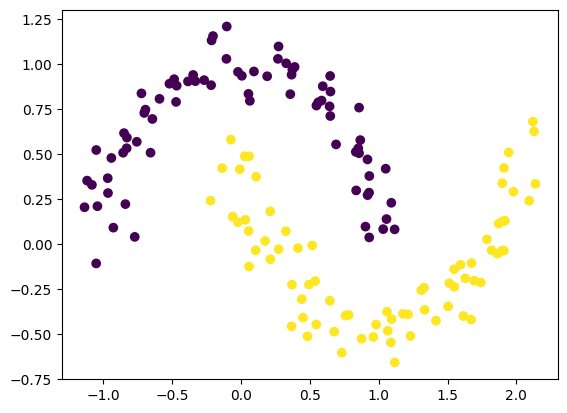

In [2]:
X,y = make_moons(150, noise=0.1, random_state=42)
plt.scatter(X[:,0],X[:,1],c=y)
plt.show()

___Tanh or Relu function___

In [3]:
model1 = Sequential()

model1.add(Input((X.shape[1],)))
model1.add(Dense(2,activation='tanh'))       #Same happens when we use relu
model1.add(Dense(1,activation='sigmoid'))

In [4]:
print("Initial weights:\n")
weights1 = model1.get_weights()
print(weights1)

#Set them to zero for zero initialization
weights1[0] = np.zeros(shape=weights1[0].shape)
weights1[1] = np.zeros(shape=weights1[1].shape)
weights1[2] = np.zeros(shape=weights1[2].shape)
weights1[3] = np.zeros(shape=weights1[3].shape)

print("\n\nZero initialized weights:\n")
print(weights1)

#Set weights
model1.set_weights(weights1)

Initial weights:

[array([[-0.8983904 ,  0.06215441],
       [ 0.10108519,  0.16721666]], dtype=float32), array([0., 0.], dtype=float32), array([[ 0.8288239 ],
       [-0.49745452]], dtype=float32), array([0.], dtype=float32)]


Zero initialized weights:

[array([[0., 0.],
       [0., 0.]]), array([0., 0.]), array([[0.],
       [0.]]), array([0.])]


In [5]:
model1.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['Accuracy'])
history1=model1.fit(X,y,epochs=100,verbose=1)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - Accuracy: 0.4733 - loss: 0.6932  
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Accuracy: 0.5000 - loss: 0.6932 
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Accuracy: 0.5000 - loss: 0.6932 
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Accuracy: 0.5000 - loss: 0.6932 
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Accuracy: 0.5000 - loss: 0.6932 
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - Accuracy: 0.5000 - loss: 0.6932 
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - Accuracy: 0.5000 - loss: 0.6932 
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Accuracy: 0.5000 - loss: 0.6932 
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - Accuracy: 0.5000 - loss: 0.6931 
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Accuracy: 0.5000 - loss: 0.6931 
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Accuracy: 0.5000 - loss: 0.6932 
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Accuracy: 0.5000 - lo

In [6]:
#Even after training model weights are the same
model1.get_weights()

[array([[0., 0.],
        [0., 0.]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.],
        [0.]], dtype=float32),
 array([0.00329401], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 6s 582us/step


<Axes: >

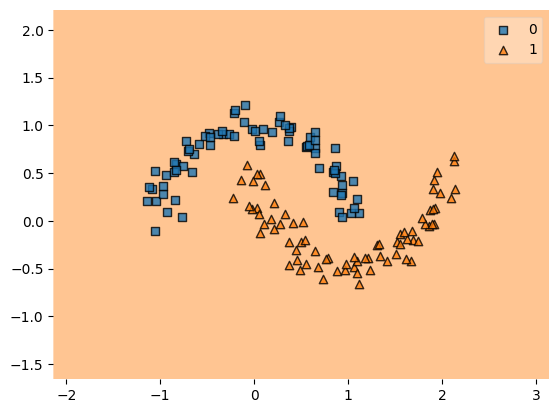

In [7]:
plot_decision_regions(X,y,model1)

- All weights and bias stays zero
- If all weights and bias are zero then in   
$z = w^T x + b = 0$ then  
Tanh and Relu activation function output zero  
Hence, all layers except the first one gets zero as input, and all outputs will be the same (0 for tanh and relu). The outputs from each node is used in calculating the derivatives and hence, the derivatives also turns out to be zero (shown below mathematically) and hence model does not learn at all (no change in weights)

![WhatsApp Image 2026-02-28 at 3.30.08 PM.jpeg](<attachment:WhatsApp Image 2026-02-28 at 3.30.08 PM.jpeg>)
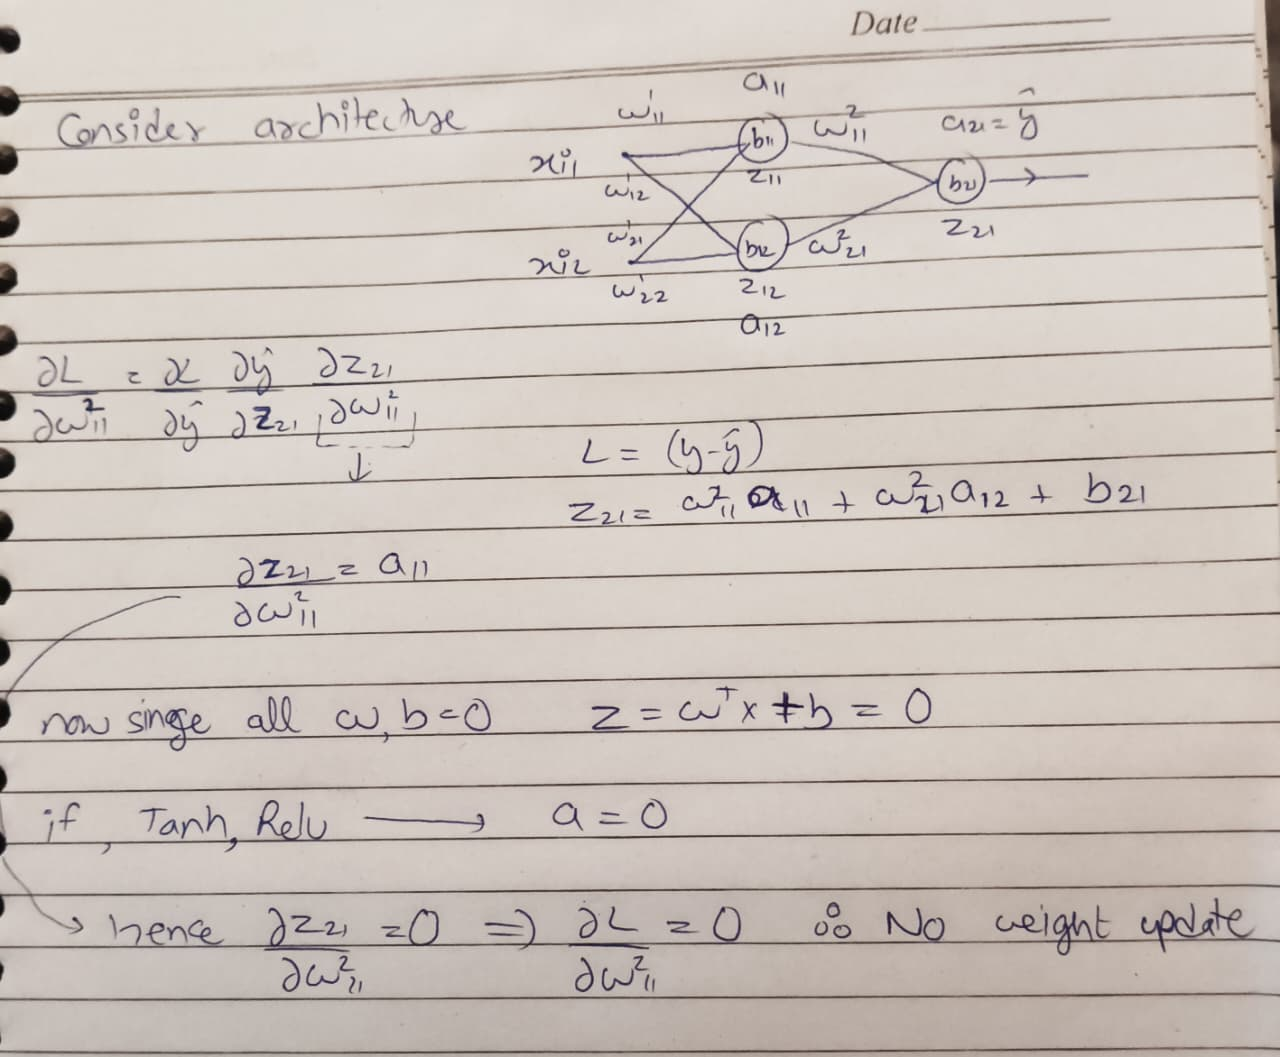

___Sigmoid activation function___

In [8]:
model2 = Sequential()

model2.add(Input((X.shape[1],)))
model2.add(Dense(128,activation='sigmoid'))      
model2.add(Dense(1,activation='sigmoid'))

In [9]:
print("Initial weights:\n")
weights2 = model2.get_weights()
print(weights2)

#Set them to zero for zero initialization
weights2[0] = np.zeros(shape=weights2[0].shape)
weights2[1] = np.zeros(shape=weights2[1].shape)
weights2[2] = np.zeros(shape=weights2[2].shape)
weights2[3] = np.zeros(shape=weights2[3].shape)

print("\n\nZero initialized weights:\n")
print(weights2)

#Set weights
model2.set_weights(weights2)

Initial weights:

[array([[ 1.03745162e-02,  4.54996079e-02, -2.10851192e-01,
        -2.79131830e-02, -2.04023659e-01,  1.28394410e-01,
         1.43161848e-01, -1.28414527e-01,  1.49282217e-02,
        -1.94073200e-01, -1.92844212e-01, -1.57419533e-01,
         1.88682079e-02,  2.05773190e-01,  1.60725191e-01,
        -3.25753838e-02, -7.76470900e-02, -5.88688850e-02,
        -1.80196226e-01, -1.39852732e-01,  2.89726853e-02,
         5.65156341e-03,  1.83818892e-01,  1.25836447e-01,
         6.59102052e-02,  2.07222059e-01, -1.87982664e-01,
        -7.26485401e-02,  1.74243107e-01,  6.18580133e-02,
        -1.53973997e-02, -1.61809891e-01,  8.24127644e-02,
        -1.03322409e-01, -9.49968696e-02, -1.32989749e-01,
         1.67304724e-02, -2.01591700e-01,  1.60733387e-01,
        -1.70832753e-01, -2.55419910e-02, -9.40093398e-02,
         9.56468731e-02,  1.06053695e-01, -7.21252710e-02,
         3.71858031e-02,  8.71376842e-02,  8.45044404e-02,
        -1.70025259e-01,  1.86137408e

In [10]:
model2.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['Accuracy'])
history2=model2.fit(X,y,epochs=100,verbose=1)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - Accuracy: 0.5000 - loss: 0.6946  
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - Accuracy: 0.5000 - loss: 0.6936 
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - Accuracy: 0.5000 - loss: 0.6937 
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - Accuracy: 0.3933 - loss: 0.6941 
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Accuracy: 0.4600 - loss: 0.6940 
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Accuracy: 0.5000 - loss: 0.6938 
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - Accuracy: 0.5000 - loss: 0.6933 
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - Accuracy: 0.5000 - loss: 0.6933 
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - Accuracy: 0.5000 - loss: 0.6937 
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - Accuracy: 0.5000 - loss: 0.6939 
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - Accuracy: 0.5000 - loss: 0.6932 
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - Accuracy: 0.5000 - lo

In [11]:
model2.get_weights()

[array([[-0.7337181, -0.7337181, -0.7337181, -0.7337181, -0.7337181,
         -0.7337181, -0.7337181, -0.7337181, -0.7337181, -0.7337181,
         -0.7337181, -0.7337181, -0.7337181, -0.7337181, -0.7337181,
         -0.7337181, -0.7337181, -0.7337181, -0.7337181, -0.7337181,
         -0.7337181, -0.7337181, -0.7337181, -0.7337181, -0.7337181,
         -0.7337181, -0.7337181, -0.7337181, -0.7337181, -0.7337181,
         -0.7337181, -0.7337181, -0.7337181, -0.7337181, -0.7337181,
         -0.7337181, -0.7337181, -0.7337181, -0.7337181, -0.7337181,
         -0.7337181, -0.7337181, -0.7337181, -0.7337181, -0.7337181,
         -0.7337181, -0.7337181, -0.7337181, -0.7337181, -0.7337181,
         -0.7337181, -0.7337181, -0.7337181, -0.7337181, -0.7337181,
         -0.7337181, -0.7337181, -0.7337181, -0.7337181, -0.7337181,
         -0.7337181, -0.7337181, -0.7337181, -0.7337181, -0.7337181,
         -0.7337181, -0.7337181, -0.7337181, -0.7337181, -0.7337181,
         -0.7337181, -0.7337181, -

Notice that, any array of weights and bias have all the same weights and biases

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 7s 700us/step


<Axes: >

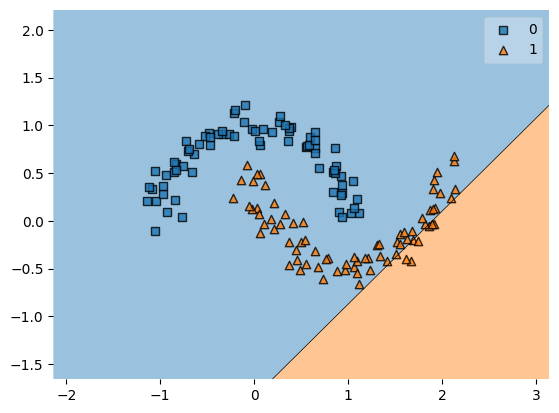

In [12]:
plot_decision_regions(X,y, model2)

Model is acting as if it has only a single neuron in each layer

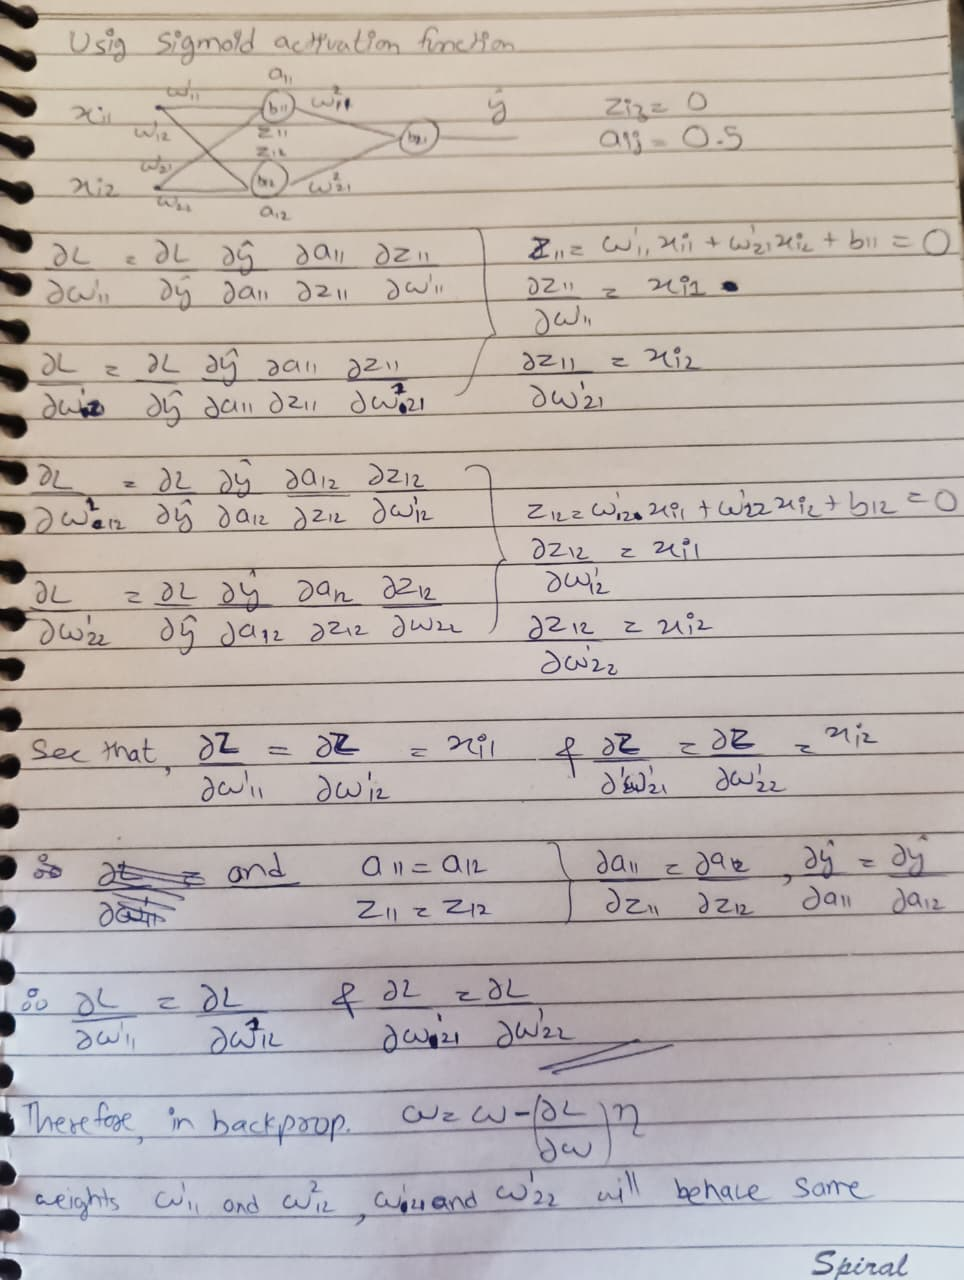

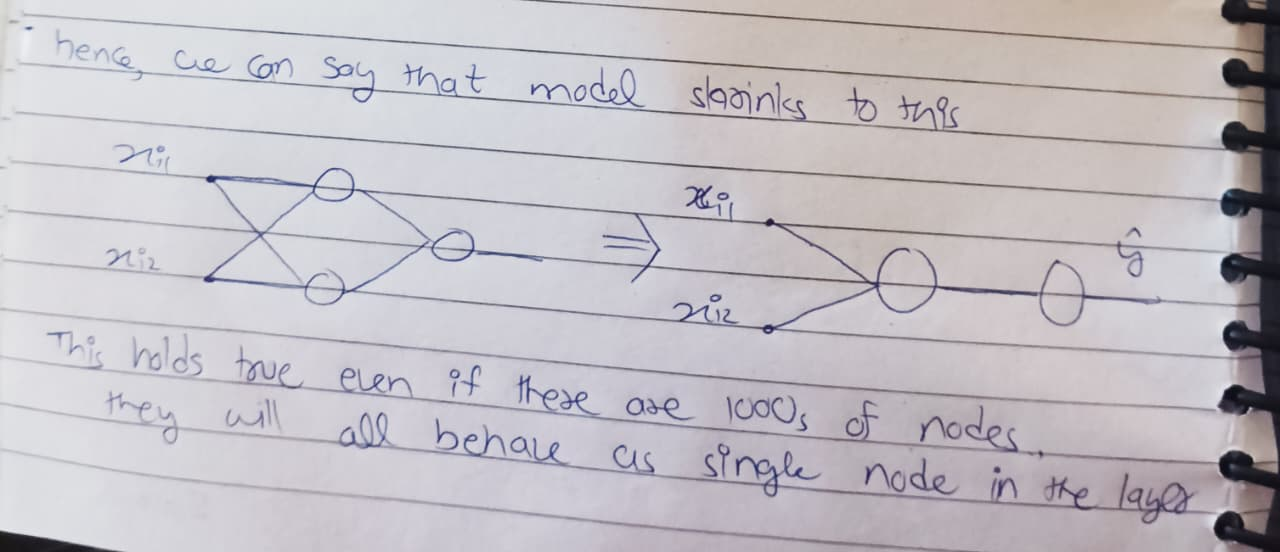

#### ___Summary___
 When applying Zero initialization:
 - If tanh, relu is used: The, outputs from each layer except input layer is zero, which makes derivatives zero and hence model does not train at all.

 - If sigmoid is used: The outputs from each layer (except input layer) is 0.5, hence all weights coming from a node are equal. This makes the model behave as linear model where each layer have practically only one single neuron

### 2. Contant initialization
All weights and bais are initialized with same contant value

- Similar thing will happen as happened in sigmoid case, model will behave as linear model where each layer have practicallly single neuron

In [17]:
model3 = Sequential()

model3.add(Input((X.shape[1],)))
model3.add(Dense(16, activation='relu'))
model3.add(Dense(1, activation='sigmoid'))

weights3 = model3.get_weights()
print("Original weights\n\n",weights3)

weights3[0] = np.ones(shape=weights3[0].shape)*0.1
weights3[1] = np.ones(shape=weights3[1].shape)*0.1
weights3[2] = np.ones(shape=weights3[2].shape)*0.1
weights3[3] = np.ones(shape=weights3[3].shape)*0.1

model3.set_weights(weights3)
print("Constant initialized weights\n\n",weights3)

Original weights

 [array([[ 0.17856836,  0.21487588,  0.23740315,  0.1339376 , -0.3017133 ,
         0.28529316, -0.49380863,  0.46170497,  0.10445541,  0.3052464 ,
         0.46159172, -0.40758526, -0.12268177,  0.35310668, -0.5230142 ,
        -0.48998782],
       [ 0.02527368,  0.46972287,  0.40863317,  0.47281313,  0.3610555 ,
         0.1442985 ,  0.27258152, -0.5599027 ,  0.10398006, -0.35572785,
        -0.06069279,  0.13910353,  0.16278404,  0.23999155,  0.22858989,
         0.49598515]], dtype=float32), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
      dtype=float32), array([[ 0.08002675],
       [ 0.2557655 ],
       [-0.20977172],
       [ 0.30731755],
       [-0.11419341],
       [ 0.39671123],
       [-0.30533075],
       [ 0.15056843],
       [-0.02566504],
       [ 0.31740856],
       [ 0.38144886],
       [-0.0796932 ],
       [ 0.0352903 ],
       [ 0.05384272],
       [-0.04661685],
       [ 0.44283545]], dtype=float32), array([0.], dtype=

In [18]:
model3.compile(optimizer='adam', loss='binary_crossentropy',metrics=['Accuracy'])
history3 = model3.fit(X,y, epochs=100, verbose=1)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - Accuracy: 0.5000 - loss: 0.7007  
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Accuracy: 0.5000 - loss: 0.6963 
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Accuracy: 0.5000 - loss: 0.6925 
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - Accuracy: 0.5000 - loss: 0.6896 
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - Accuracy: 0.5000 - loss: 0.6867 
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - Accuracy: 0.5000 - loss: 0.6839 
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Accuracy: 0.5000 - loss: 0.6813 
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - Accuracy: 0.5000 - loss: 0.6790 
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - Accuracy: 0.5000 - loss: 0.6766 
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Accuracy: 0.5000 - loss: 0.6743 
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Accuracy: 0.5000 - loss: 0.6720 
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - Accuracy: 0.5000 - lo

In [19]:
model3.get_weights()

[array([[ 0.18875457,  0.18875457,  0.18875457,  0.18875457,  0.18875457,
          0.18875457,  0.18875457,  0.18875457,  0.18875457,  0.18875457,
          0.18875457,  0.18875457,  0.18875457,  0.18875457,  0.18875457,
          0.18875457],
        [-0.3371133 , -0.3371133 , -0.3371133 , -0.3371133 , -0.3371133 ,
         -0.3371133 , -0.3371133 , -0.3371133 , -0.3371133 , -0.3371133 ,
         -0.3371133 , -0.3371133 , -0.3371133 , -0.3371133 , -0.3371133 ,
         -0.3371133 ]], dtype=float32),
 array([0.09663855, 0.09663855, 0.09663855, 0.09663855, 0.09663855,
        0.09663855, 0.09663855, 0.09663855, 0.09663855, 0.09663855,
        0.09663855, 0.09663855, 0.09663855, 0.09663855, 0.09663855,
        0.09663855], dtype=float32),
 array([[0.36359406],
        [0.36359406],
        [0.36359406],
        [0.36359406],
        [0.36359406],
        [0.36359406],
        [0.36359406],
        [0.36359406],
        [0.36359406],
        [0.36359406],
        [0.36359406],
        [0

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 6s 623us/step


<Axes: >

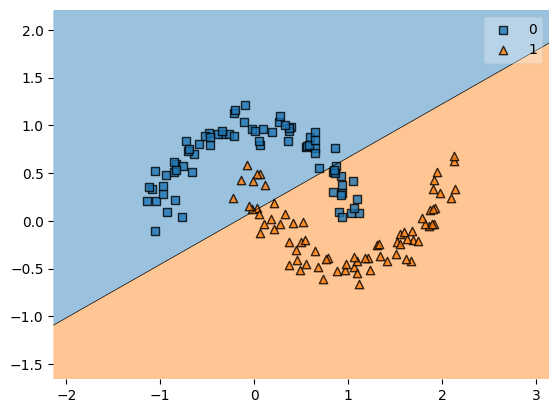

In [20]:
plot_decision_regions(X,y,model3)

### Random initialization 
1. With Small values
    - i.e weights are initialized as 
    ```python
    np.random.rand(X.shape)*0.01 or *0.1

    ```
    - Here Vanishing Gradient Problem will be seen. Because, if weights are small --> summation is small --> output after activation is small --> Gradients will be small --> in deep neural networks, those gradients are multiplied several times, hence, final gradient in initial layers will be even smaller --> no significant weights updation

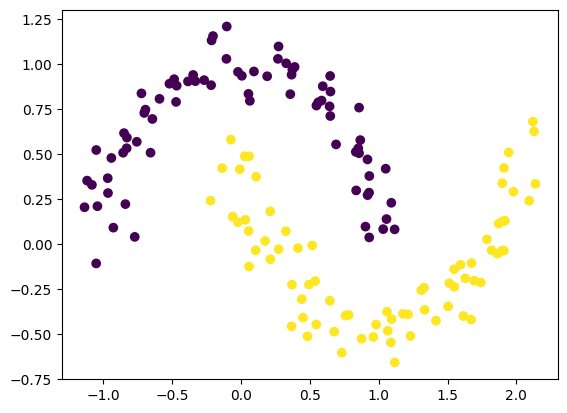

In [22]:
plt.scatter(X[:,0],X[:,1],c=y)

In [54]:
model4 = Sequential()
model4.add(Input(shape=(X.shape[1],)))
model4.add(Dense(8, activation='tanh'))
model4.add(Dense(8, activation='tanh'))
model4.add(Dense(1, activation='sigmoid'))

weights4 = model4.get_weights()
print("Original weights:\n\n", weights4)

weights4[0] = np.random.rand(weights4[0].shape[0], weights4[0].shape[1])*0.01
weights4[1] = np.random.rand(weights4[1].shape[0],)*0.01
weights4[2] = np.random.rand(weights4[2].shape[0], weights4[2].shape[1])*0.01
weights4[3] = np.random.rand(weights4[3].shape[0],)*0.01
weights4[4] = np.random.rand(weights4[4].shape[0], weights4[4].shape[1])*0.01
weights4[5] = np.random.rand(weights4[5].shape[0],)*0.01

model4.set_weights(weights4)
print("New weights:\n\n", weights4)

Original weights:

 [array([[-0.00134355, -0.03661138, -0.2884384 ,  0.5078763 ,  0.560485  ,
        -0.09388101,  0.20108634,  0.09860545],
       [ 0.05267298, -0.02706164,  0.52029157, -0.3934703 , -0.6809813 ,
        -0.00830203,  0.7332958 , -0.66749865]], dtype=float32), array([0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32), array([[ 0.49157137,  0.5793354 ,  0.27621442, -0.14620772, -0.04724783,
        -0.5980391 ,  0.10142237,  0.36666757],
       [-0.17283246,  0.10705376, -0.26814276, -0.4200816 , -0.2418496 ,
        -0.06944358,  0.59475714,  0.35703748],
       [-0.17485878, -0.42331666,  0.50308305, -0.1203216 ,  0.17125225,
         0.5638897 ,  0.14624262,  0.44408995],
       [ 0.45330364, -0.10928231,  0.25520486, -0.33187377, -0.3588501 ,
         0.3941874 , -0.38747957, -0.11058915],
       [-0.16032222,  0.16563666, -0.2112656 , -0.37140983, -0.5017564 ,
         0.55027837, -0.04657388, -0.35592481],
       [-0.5497734 ,  0.07477379,  0.5337201 ,  0.5721732 ,

In [55]:
model4.compile(optimizer='adam', loss='binary_crossentropy', metrics=['Accuracy'])
histroy4 = model4.fit(X,y, epochs=100, verbose=1)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - Accuracy: 0.5000 - loss: 0.6932
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - Accuracy: 0.5000 - loss: 0.6932 
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Accuracy: 0.5000 - loss: 0.6931 
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Accuracy: 0.5000 - loss: 0.6931 
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Accuracy: 0.5000 - loss: 0.6930 
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - Accuracy: 0.5000 - loss: 0.6927 
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - Accuracy: 0.5600 - loss: 0.6923 
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - Accuracy: 0.7533 - loss: 0.6916 
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - Accuracy: 0.7867 - loss: 0.6906 
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Accuracy: 0.8000 - loss: 0.6893 
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - Accuracy: 0.7867 - loss: 0.6870 
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - Accuracy: 0.7867 - loss

Now i will get outputs from each layer and then visualize their range

In [57]:
# To get outputs 
from keras.models import Model

outputs = [layer.output for layer in model4.layers]

layers_output = Model(
    inputs = model4.input,
    outputs = outputs
)

layers_output.predict(X)

AttributeError: The layer sequential_14 has never been called and thus has no defined input.